# Data Discovery: MovieLens & TMDb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load Data

In [2]:
movies_df = pd.read_csv('../data/processed/movies_final.csv')
ratings_df = pd.read_csv('../data/processed/ratings_final.csv')
display(movies_df.head())
display(ratings_df.head())


,movieId,title,genres,tmdbId,clean_genres,language,vote_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,862.0,Animation|Comedy|Family,EN,5415.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,8844.0,Adventure|Fantasy|Family,EN,2413.0
2,3,Grumpier Old Men (1995),Comedy|Romance,15602.0,Romance|Comedy,EN,92.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,31357.0,Comedy|Drama|Romance,EN,34.0
4,5,Father of the Bride Part II (1995),Comedy,11862.0,Comedy,EN,173.0


,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


## 2. Rating Distribution

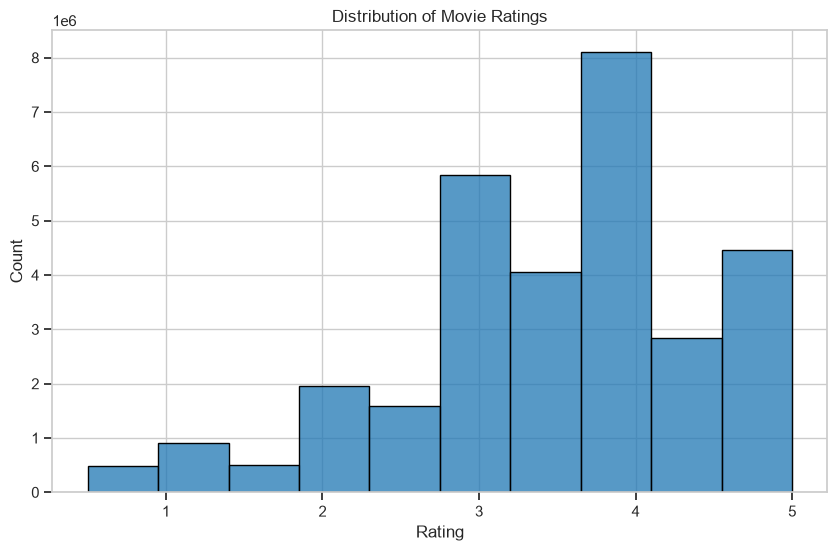

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings_df[['rating']], x='rating', bins=10, kde=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(f'{FIG_DIR}/01_rating_distribution.png', bbox_inches='tight')
plt.show()


## 3. Genre Popularity

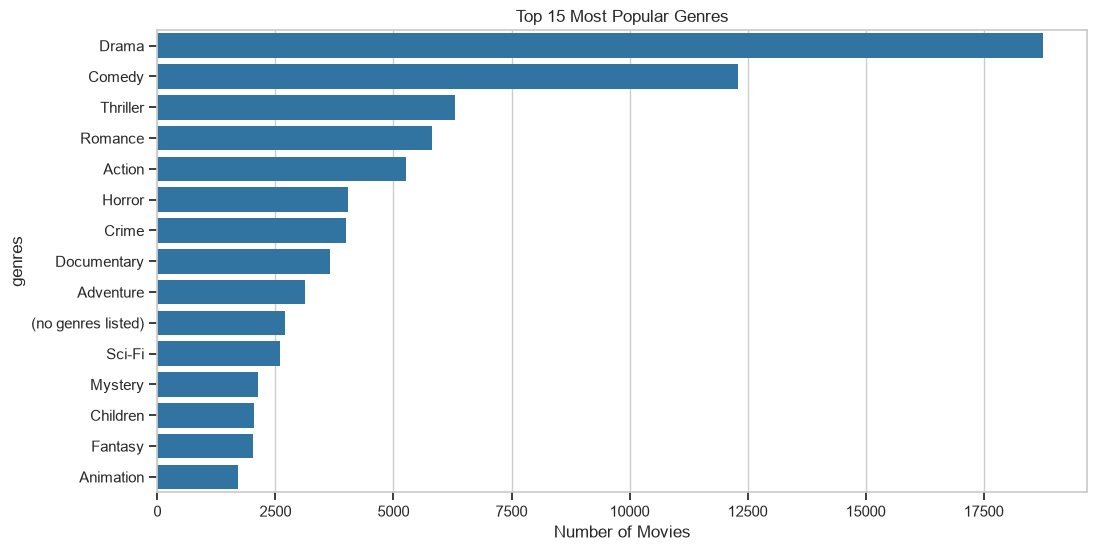

In [4]:
all_genres = movies_df['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 15 Most Popular Genres')
plt.xlabel('Number of Movies')
plt.savefig(f'{FIG_DIR}/02_genre_popularity.png', bbox_inches='tight')
plt.show()


## 4. Language Distribution

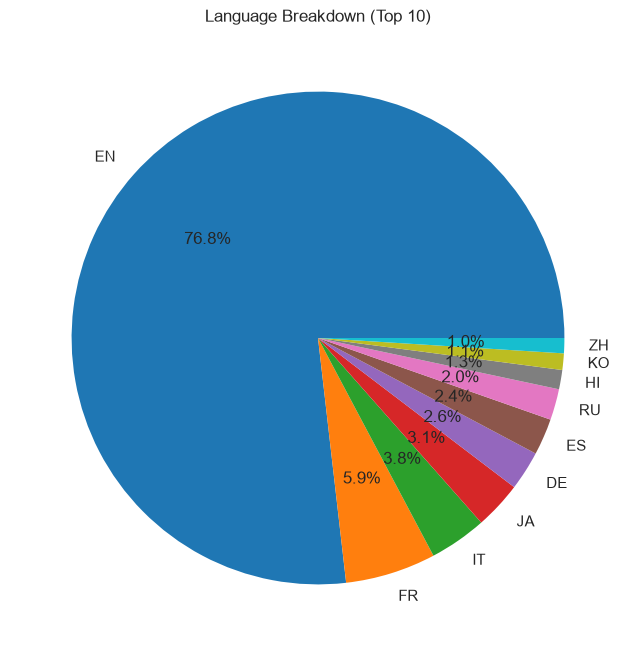

In [5]:
if 'language' in movies_df.columns:
    lang_counts = movies_df['language'].value_counts().head(10)
    plt.figure(figsize=(8, 8))
    plt.pie(lang_counts.tolist(), labels=lang_counts.index.tolist(), autopct='%1.1f%%')
    plt.title('Language Breakdown (Top 10)')
    plt.savefig(f'{FIG_DIR}/03_language_distribution.png', bbox_inches='tight')
    plt.show()